In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
df = pd.read_csv("uber-ride-bookings.csv")
df.head()

,Date,Time,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,...,Reason for cancelling by Customer,Cancelled Rides by Driver,Driver Cancellation Reason,Incomplete Rides,Incomplete Rides Reason,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Payment Method
0,2024-03-23,12:29:38,"""CNR5884300""",No Driver Found,"""CID1982111""",eBike,Palam Vihar,Jhilmil,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2024-11-29,18:01:39,"""CNR1326809""",Incomplete,"""CID4604802""",Go Sedan,Shastri Nagar,Gurgaon Sector 56,4.9,14.0,...,NaN,NaN,NaN,1.0,Vehicle Breakdown,237.0,5.73,NaN,NaN,UPI
2,2024-08-23,08:56:10,"""CNR8494506""",Completed,"""CID9202816""",Auto,Khandsa,Malviya Nagar,13.4,25.8,...,NaN,NaN,NaN,NaN,NaN,627.0,13.58,4.9,4.9,Debit Card
3,2024-10-21,17:17:25,"""CNR8906825""",Completed,"""CID2610914""",Premier Sedan,Central Secretariat,Inderlok,13.1,28.5,...,NaN,NaN,NaN,NaN,NaN,416.0,34.02,4.6,5.0,UPI
4,2024-09-16,22:08:00,"""CNR1950162""",Completed,"""CID9933542""",Bike,Ghitorni Village,Khan Market,5.3,19.6,...,NaN,NaN,NaN,NaN,NaN,737.0,48.21,4.1,4.3,UPI


In [7]:
df.shape

(150000, 21)

In [8]:
df.columns

Index(['Date', 'Time', 'Booking ID', 'Booking Status', 'Customer ID',
       'Vehicle Type', 'Pickup Location', 'Drop Location', 'Avg VTAT',
       'Avg CTAT', 'Cancelled Rides by Customer',
       'Reason for cancelling by Customer', 'Cancelled Rides by Driver',
       'Driver Cancellation Reason', 'Incomplete Rides',
       'Incomplete Rides Reason', 'Booking Value', 'Ride Distance',
       'Driver Ratings', 'Customer Rating', 'Payment Method'],
      dtype='object')

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 21 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   Date                               150000 non-null  object 
 1   Time                               150000 non-null  object 
 2   Booking ID                         150000 non-null  object 
 3   Booking Status                     150000 non-null  object 
 4   Customer ID                        150000 non-null  object 
 5   Vehicle Type                       150000 non-null  object 
 6   Pickup Location                    150000 non-null  object 
 7   Drop Location                      150000 non-null  object 
 8   Avg VTAT                           139500 non-null  float64
 9   Avg CTAT                           102000 non-null  float64
 10  Cancelled Rides by Customer        10500 non-null   float64
 11  Reason for cancelling by Customer  1050

In [10]:
df.describe()

,Avg VTAT,Avg CTAT,Cancelled Rides by Customer,Cancelled Rides by Driver,Incomplete Rides,Booking Value,Ride Distance,Driver Ratings,Customer Rating
count,139500.000000,102000.000000,10500.0,27000.0,9000.0,102000.000000,102000.000000,93000.000000,93000.000000
mean,8.456352,29.149636,1.0,1.0,1.0,508.295912,24.637012,4.230992,4.404584
std,3.773564,8.902577,0.0,0.0,0.0,395.805774,14.002138,0.436871,0.437819
min,2.000000,10.000000,1.0,1.0,1.0,50.000000,1.000000,3.000000,3.000000
25%,5.300000,21.600000,1.0,1.0,1.0,234.000000,12.460000,4.100000,4.200000
50%,8.300000,28.800000,1.0,1.0,1.0,414.000000,23.720000,4.300000,4.500000
75%,11.300000,36.800000,1.0,1.0,1.0,689.000000,36.820000,4.600000,4.800000
max,20.000000,45.000000,1.0,1.0,1.0,4277.000000,50.000000,5.000000,5.000000


In [11]:
df.isnull().sum()

Date                                      0
Time                                      0
Booking ID                                0
Booking Status                            0
Customer ID                               0
Vehicle Type                              0
Pickup Location                           0
Drop Location                             0
Avg VTAT                              10500
Avg CTAT                              48000
Cancelled Rides by Customer          139500
Reason for cancelling by Customer    139500
Cancelled Rides by Driver            123000
Driver Cancellation Reason           123000
Incomplete Rides                     141000
Incomplete Rides Reason              141000
Booking Value                         48000
Ride Distance                         48000
Driver Ratings                        57000
Customer Rating                       57000
Payment Method                        48000
dtype: int64

In [29]:
df['Avg VTAT'] = df['Avg VTAT'].fillna(df['Avg VTAT'].median())
df['Avg CTAT'] = df['Avg CTAT'].fillna(df['Avg CTAT'].median())

In [22]:
df['Driver Ratings'] = df['Driver Ratings'].fillna(df['Driver Ratings'].mean())
df['Customer Rating'] = df['Customer Rating'].fillna(df['Customer Rating'].mean())

In [23]:
df['Payment Method'] = df['Payment Method'].fillna('Unknown')

In [24]:
df.isnull().sum()

Date                                      0
Time                                      0
Booking ID                                0
Booking Status                            0
Customer ID                               0
Vehicle Type                              0
Pickup Location                           0
Drop Location                             0
Avg VTAT                                  0
Avg CTAT                              48000
Cancelled Rides by Customer          139500
Reason for cancelling by Customer    139500
Cancelled Rides by Driver            123000
Driver Cancellation Reason           123000
Incomplete Rides                     141000
Incomplete Rides Reason              141000
Booking Value                             0
Ride Distance                             0
Driver Ratings                            0
Customer Rating                           0
Payment Method                            0
dtype: int64

In [25]:
df['Cancelled Rides by Customer'] = df['Cancelled Rides by Customer'].fillna(0)
df['Reason for cancelling by Customer'] = df['Reason for cancelling by Customer'].fillna('Not Cancelled')

In [26]:
df['Cancelled Rides by Driver'] = df['Cancelled Rides by Driver'].fillna(0)
df['Driver Cancellation Reason'] = df['Driver Cancellation Reason'].fillna('Not Cancelled')

In [27]:
df['Incomplete Rides'] = df['Incomplete Rides'].fillna(0)
df['Incomplete Rides Reason'] = df['Incomplete Rides Reason'].fillna('Completed')

In [30]:
df.isnull().sum()

Date                                 0
Time                                 0
Booking ID                           0
Booking Status                       0
Customer ID                          0
Vehicle Type                         0
Pickup Location                      0
Drop Location                        0
Avg VTAT                             0
Avg CTAT                             0
Cancelled Rides by Customer          0
Reason for cancelling by Customer    0
Cancelled Rides by Driver            0
Driver Cancellation Reason           0
Incomplete Rides                     0
Incomplete Rides Reason              0
Booking Value                        0
Ride Distance                        0
Driver Ratings                       0
Customer Rating                      0
Payment Method                       0
dtype: int64

In [31]:
df.head()

,Date,Time,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,...,Reason for cancelling by Customer,Cancelled Rides by Driver,Driver Cancellation Reason,Incomplete Rides,Incomplete Rides Reason,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Payment Method
0,2024-03-23,12:29:38,"""CNR5884300""",No Driver Found,"""CID1982111""",eBike,Palam Vihar,Jhilmil,8.3,28.8,...,Not Cancelled,0.0,Not Cancelled,0.0,Completed,414.0,23.72,4.230992,4.404584,Unknown
1,2024-11-29,18:01:39,"""CNR1326809""",Incomplete,"""CID4604802""",Go Sedan,Shastri Nagar,Gurgaon Sector 56,4.9,14.0,...,Not Cancelled,0.0,Not Cancelled,1.0,Vehicle Breakdown,237.0,5.73,4.230992,4.404584,UPI
2,2024-08-23,08:56:10,"""CNR8494506""",Completed,"""CID9202816""",Auto,Khandsa,Malviya Nagar,13.4,25.8,...,Not Cancelled,0.0,Not Cancelled,0.0,Completed,627.0,13.58,4.900000,4.900000,Debit Card
3,2024-10-21,17:17:25,"""CNR8906825""",Completed,"""CID2610914""",Premier Sedan,Central Secretariat,Inderlok,13.1,28.5,...,Not Cancelled,0.0,Not Cancelled,0.0,Completed,416.0,34.02,4.600000,5.000000,UPI
4,2024-09-16,22:08:00,"""CNR1950162""",Completed,"""CID9933542""",Bike,Ghitorni Village,Khan Market,5.3,19.6,...,Not Cancelled,0.0,Not Cancelled,0.0,Completed,737.0,48.21,4.100000,4.300000,UPI


In [ ]:
#Feature Engineering
#time-based features

In [32]:
df['DateTime'] = pd.to_datetime(df['Date'].astype(str) + " " + df['Time'].astype(str))

df['Hour'] = df['DateTime'].dt.hour
df['Day'] = df['DateTime'].dt.day_name()
df['Month'] = df['DateTime'].dt.month

In [ ]:
#DEMAND ANALYSIS

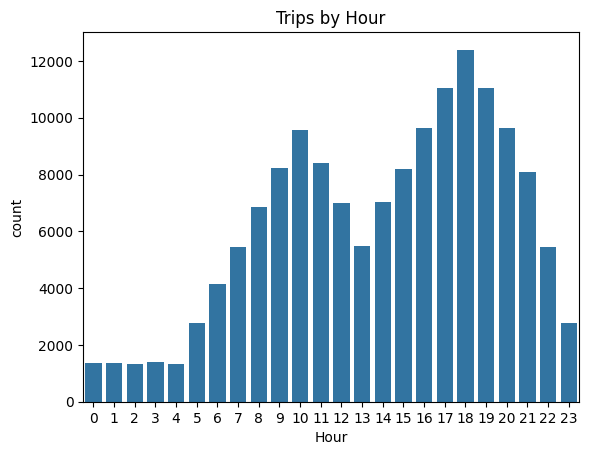

In [33]:
# TRIPS BY HOUR 
plt.figure()
sns.countplot(x='Hour', data=df)
plt.title("Trips by Hour")
plt.show()

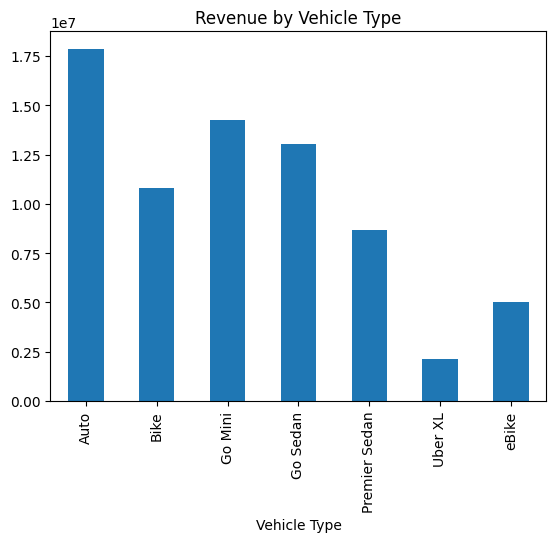

In [35]:
#REVENUE ANALYSIS
#Which vehicle generates most revenue
df.groupby('Vehicle Type')['Booking Value'].sum().plot(kind='bar')
plt.title("Revenue by Vehicle Type")
plt.show()

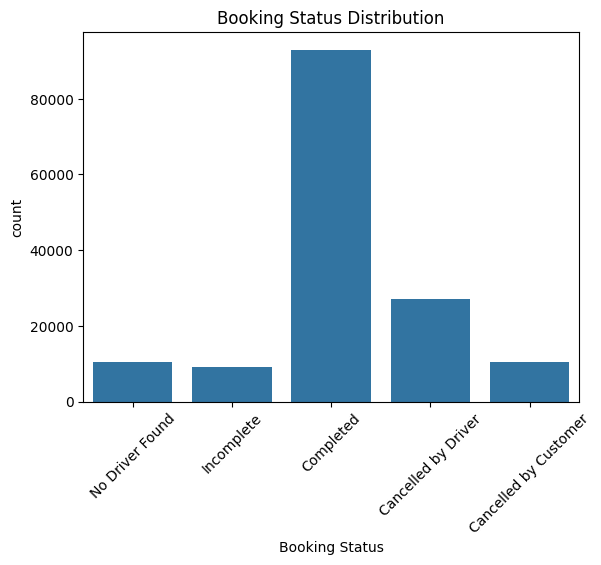

In [36]:
#CANCELLATION ANALYSIS
plt.figure()
sns.countplot(x='Booking Status', data=df)
plt.xticks(rotation=45)
plt.title("Booking Status Distribution")
plt.show()

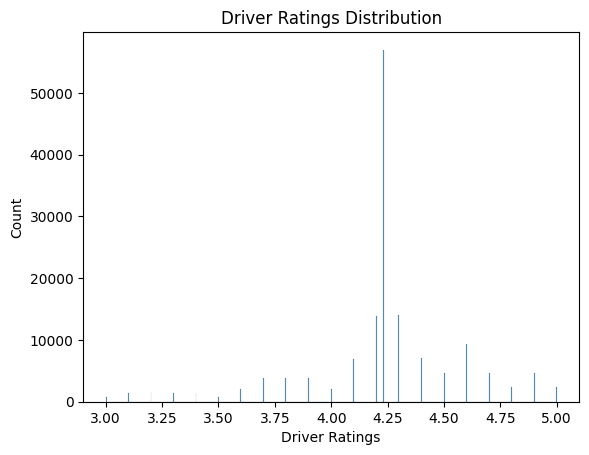

In [37]:
#RATINGS ANALYSIS
#Customer satisfaction level
plt.figure()
sns.histplot(df['Driver Ratings'])
plt.title("Driver Ratings Distribution")
plt.show()

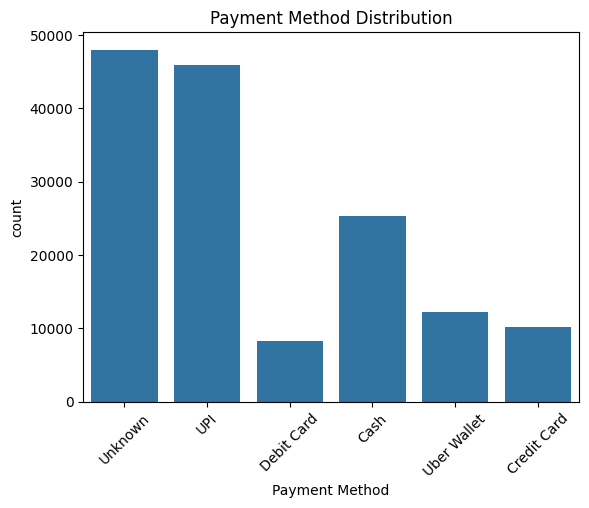

In [38]:
#PAYMENT ANALYSIS
plt.figure()
sns.countplot(x='Payment Method', data=df)
plt.xticks(rotation=45)
plt.title("Payment Method Distribution")
plt.show()
#Most preferred payment method

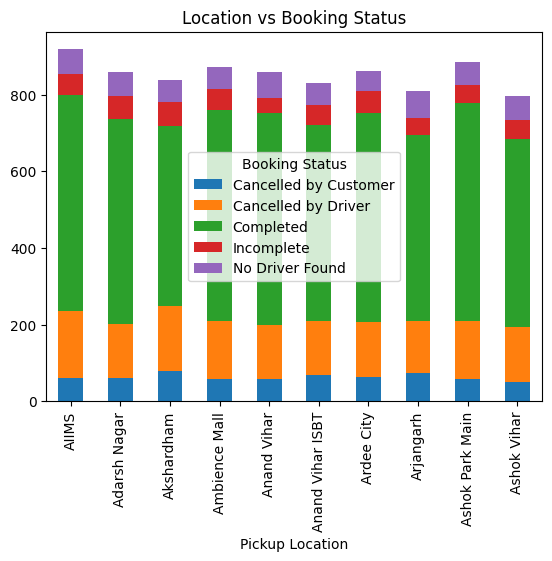

In [42]:
pd.crosstab(df['Pickup Location'], df['Booking Status']).head(10).plot(kind='bar', stacked=True)
plt.title("Location vs Booking Status")
plt.show()

In [43]:
#Calculate % of cancellations
total = len(df)

cancelled = df[df['Booking Status'] != 'Completed'].shape[0]

print("Cancellation Rate:", (cancelled / total) * 100)

Cancellation Rate: 38.0


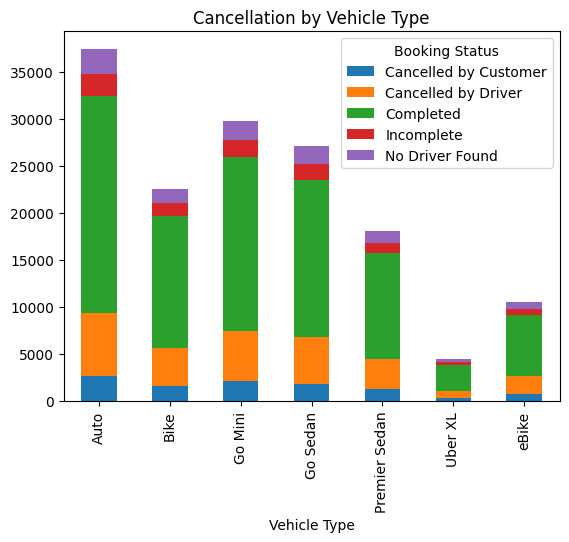

In [44]:
#Cancellation by Vehicle Type
#Which vehicle has more cancellations
pd.crosstab(df['Vehicle Type'], df['Booking Status']).plot(kind='bar', stacked=True)
plt.title("Cancellation by Vehicle Type")
plt.show()

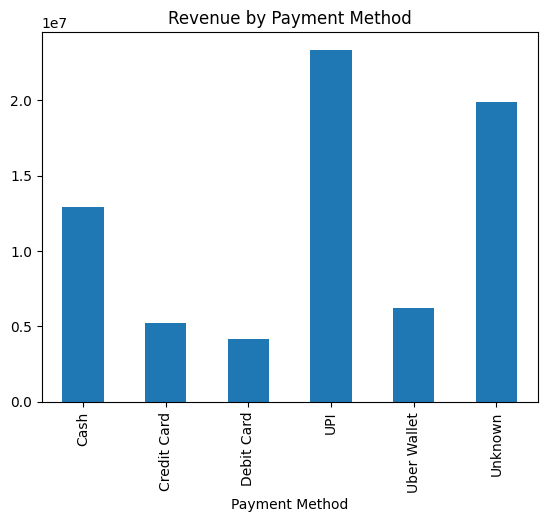

In [46]:
df.groupby('Payment Method')['Booking Value'].sum().plot(kind='bar')
plt.title("Revenue by Payment Method")
plt.show()
#Which payment brings more revenue

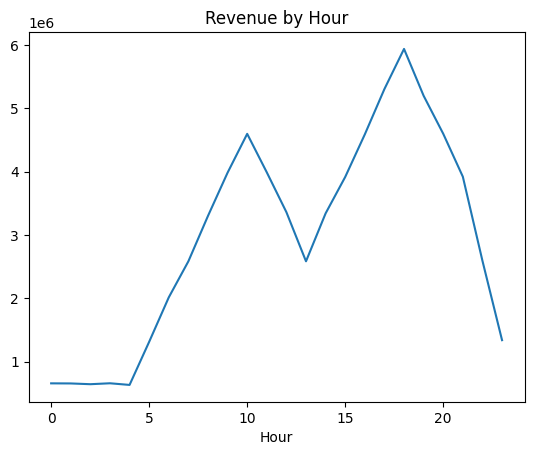

In [54]:
df.groupby('Hour')['Booking Value'].sum().plot()
plt.title("Revenue by Hour")
plt.show()
#Which time gives highest revenue

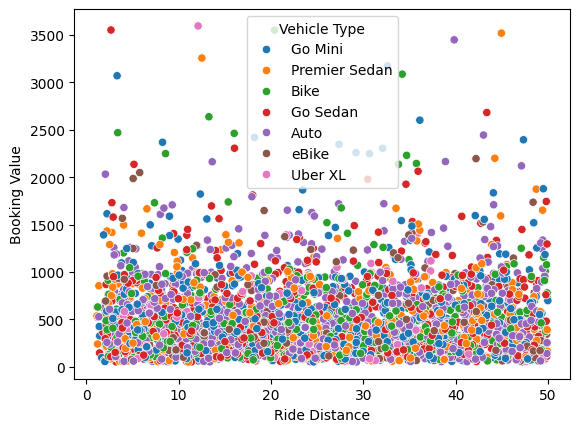

In [57]:
sample_df = df.sample(5000)

sns.scatterplot(x='Ride Distance', y='Booking Value',
                hue='Vehicle Type',
                data=sample_df)
plt.show()

In [58]:
df.to_csv("cleaned_uber_data.csv", index=False)